# Task 1: Data Loading & Deep Exploration


In [ ]:
!pip install statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_style("whitegrid")

In [ ]:
df = pd.read_csv("train.csv")
df_original = df.copy()
df.head(10)
print("Dataset Shape:", df.shape)

Dataset Shape: (9800, 18)


In [ ]:
df.info()
df.describe(include='all')
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format="%d/%m/%Y"
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format="%d/%m/%Y"
)

In [ ]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [ ]:
df['Year'] = df['Order Date'].dt.year

In [ ]:
df['Month'] = df['Order Date'].dt.month_name()

In [ ]:
df['Month_Num'] = df['Order Date'].dt.month

In [ ]:
df['Week'] = df['Order Date'].dt.isocalendar().week

In [ ]:
df['Day_of_Week'] = df['Order Date'].dt.day_name()

In [ ]:
df['Quarter'] = df['Order Date'].dt.quarter

In [ ]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month_Num"].apply(get_season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month_Num,Week,Day_of_Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,November,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,November,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,June,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,October,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,October,10,41,Tuesday,4,Autumn


In [ ]:
df["Shipping_Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

print(
    "Average Shipping Time:",
    round(df["Shipping_Days"].mean(),2),
    "days"
)

Average Shipping Time: 3.96 days


In [ ]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [ ]:
weekly_sales = (
    df.resample(
        "W",
        on="Order Date"
    )["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [ ]:
monthly_sales = (
    df.resample(
        "M",
        on="Order Date"
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
df[[
    "Order Date",
    "Year",
    "Month",
    "Week",
    "Day_of_Week",
    "Quarter",
    "Season",
    "Shipping_Days"
]].head()

,Order Date,Year,Month,Week,Day_of_Week,Quarter,Season,Shipping_Days
0,2017-11-08,2017,November,45,Wednesday,4,Autumn,3
1,2017-11-08,2017,November,45,Wednesday,4,Autumn,3
2,2017-06-12,2017,June,24,Monday,2,Summer,4
3,2016-10-11,2016,October,41,Tuesday,4,Autumn,7
4,2016-10-11,2016,October,41,Tuesday,4,Autumn,7


**Oues 1 - Which Product Category Generates the Highest Revenue?**

In [ ]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


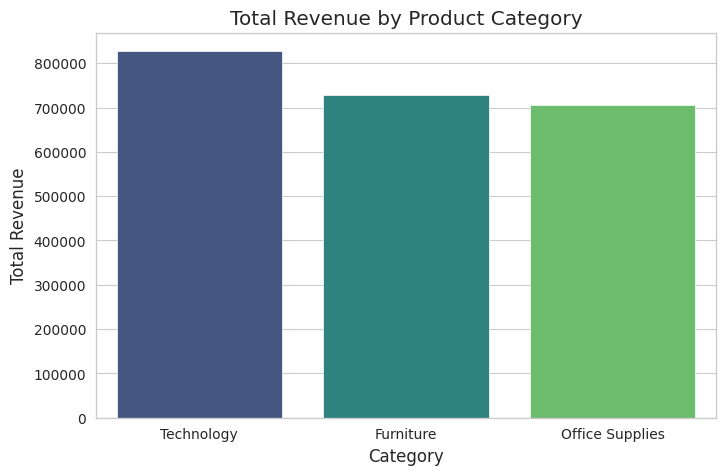

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="viridis"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")

plt.show()

The chart compares total sales generated by each product category. The Technology category with the highest sales contributes the most to overall business revenue and should be considered a priority for inventory planning and future sales forecasting.

**Ques 2 - Which Region Shows the Most Consistent Sales Growth?**

In [ ]:
region_sales = (
    df.groupby(["Year","Region"])["Sales"]
      .sum()
      .reset_index()
)

region_sales.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


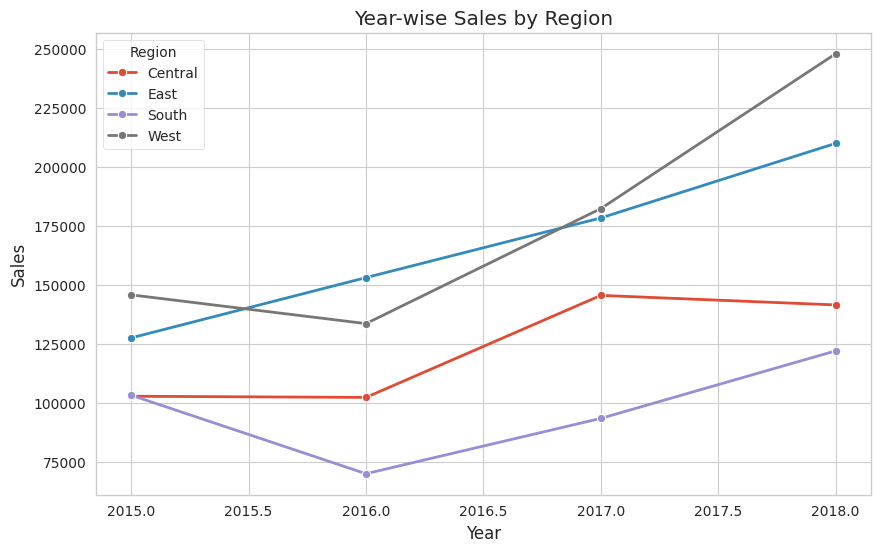

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o",
    linewidth=2
)

plt.title("Year-wise Sales by Region")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()

The East region showing the smoothest upward sales trend over multiple years can be considered the most consistent performer. Other regions with fluctuating sales may require additional business analysis to understand changing customer demand.

**Ques 3 - What is the average time between Order Date and Ship Date — and does it vary by region?**

In [ ]:
shipping_region = (
    df.groupby("Region")["Shipping_Days"]
      .mean()
      .sort_values()
)

print(shipping_region)

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping_Days, dtype: float64


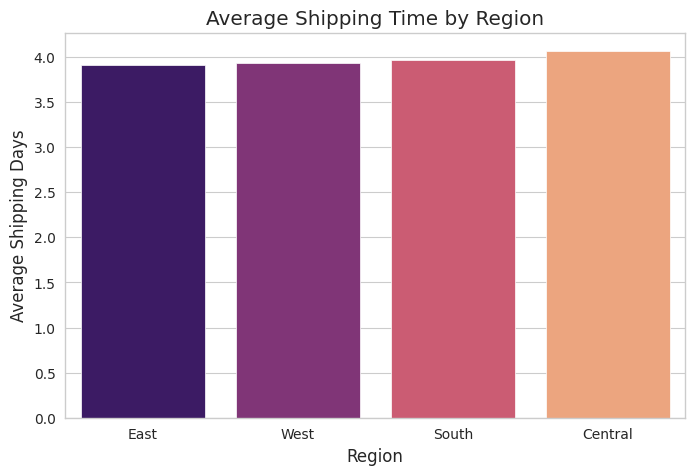

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values,
    palette="magma"
)

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.show()

Although shipping times remain fairly similar across all regions, even small differences in region may affect customer satisfaction. Regions with longer delivery times like central region here could benefit from logistics improvements.

**Ques 4 - Are there months that consistently spike across all years (seasonality)?**

In [ ]:
monthly_sales_pattern = (
    df.groupby(["Year","Month_Num"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales_pattern.head()

,Year,Month_Num,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


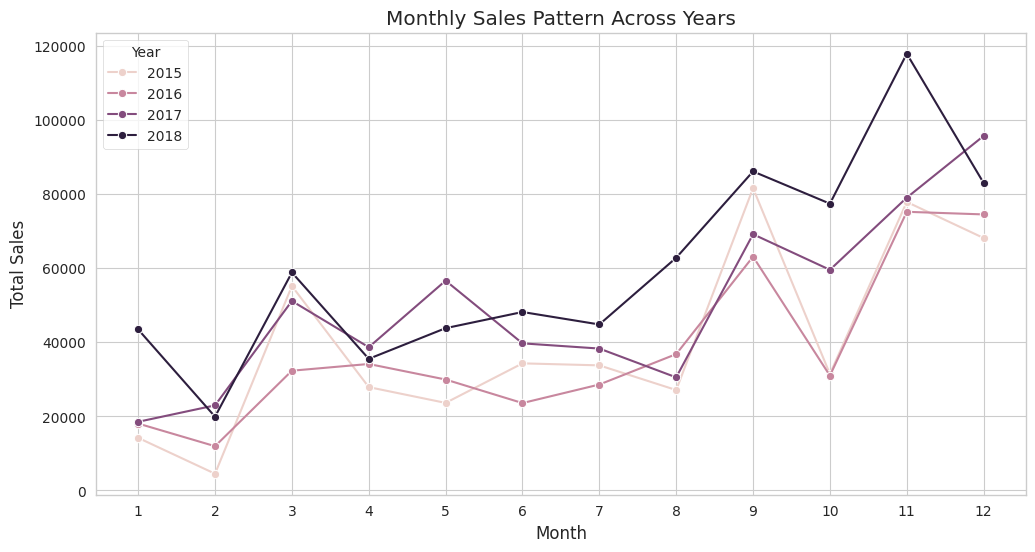

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales_pattern,
    x="Month_Num",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.xticks(range(1,13))

plt.title("Monthly Sales Pattern Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

Similar peaks across multiple years indicate seasonal buying patterns. Recognizing these recurring high-demand months helps businesses prepare inventory and optimize supply chain planning.

**Sales Distribution**

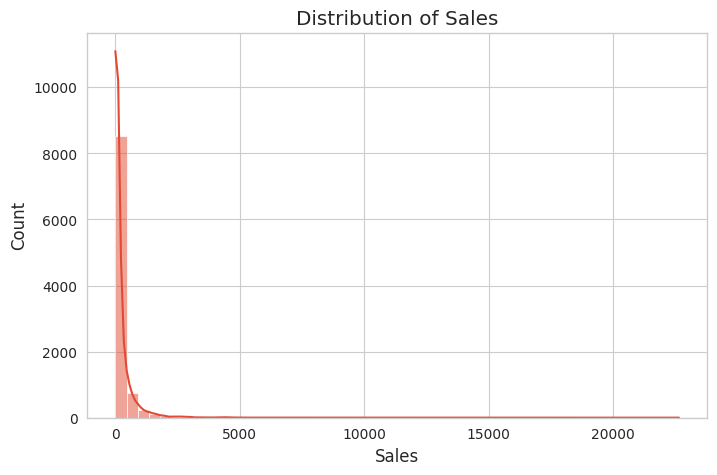

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Sales"],
    bins=50,
    kde=True
)

plt.title("Distribution of Sales")
plt.show()

The sales distribution helps identify that most orders are low-value purchases which dominate overall revenue.

**Top 10 States by Revenue**

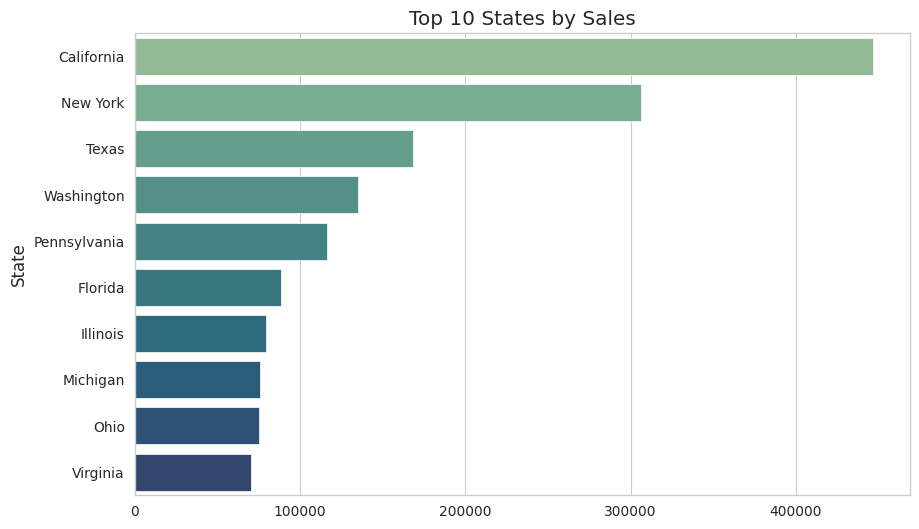

In [ ]:
top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index,
    palette="crest"
)

plt.title("Top 10 States by Sales")

plt.show()

The top-performing states i.e. California and New York contribute a significant portion of total sales. These regions represent important markets where maintaining inventory and customer engagement should remain a priority.

**Sales by Segment**

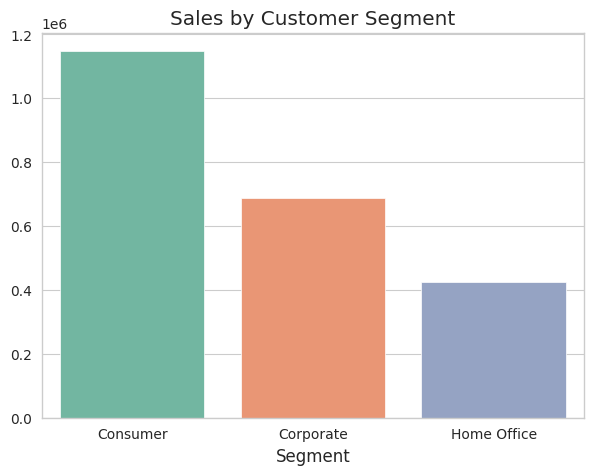

In [ ]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values,
    palette="Set2"
)

plt.title("Sales by Customer Segment")

plt.show()

Customer segments contribute differently to overall sales. Identifying the highest-performing segment helps businesses focus marketing strategies and customer retention efforts.

# Task 2: Time Series Analysis & Decomposition

In [ ]:
monthly_sales = (
    df.resample(
        "M",
        on="Order Date"
    )["Sales"]
    .sum()
)

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


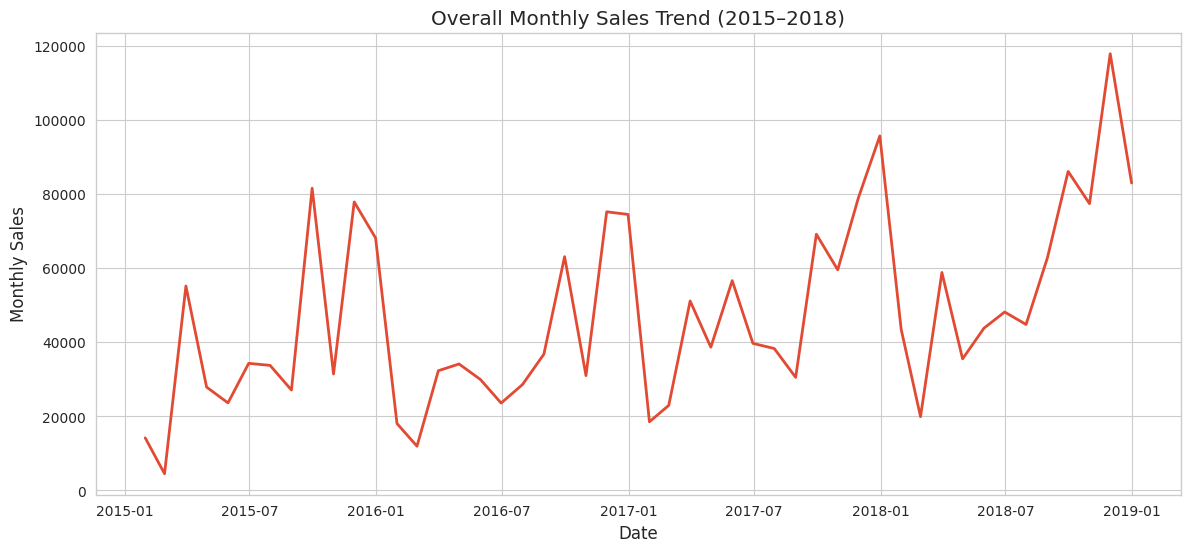

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=2
)

plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")

plt.show()

The monthly sales trend illustrates how revenue changes over time. An overall upward trend indicates business growth, while recurring peaks and dips suggest seasonal demand patterns.

In [ ]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

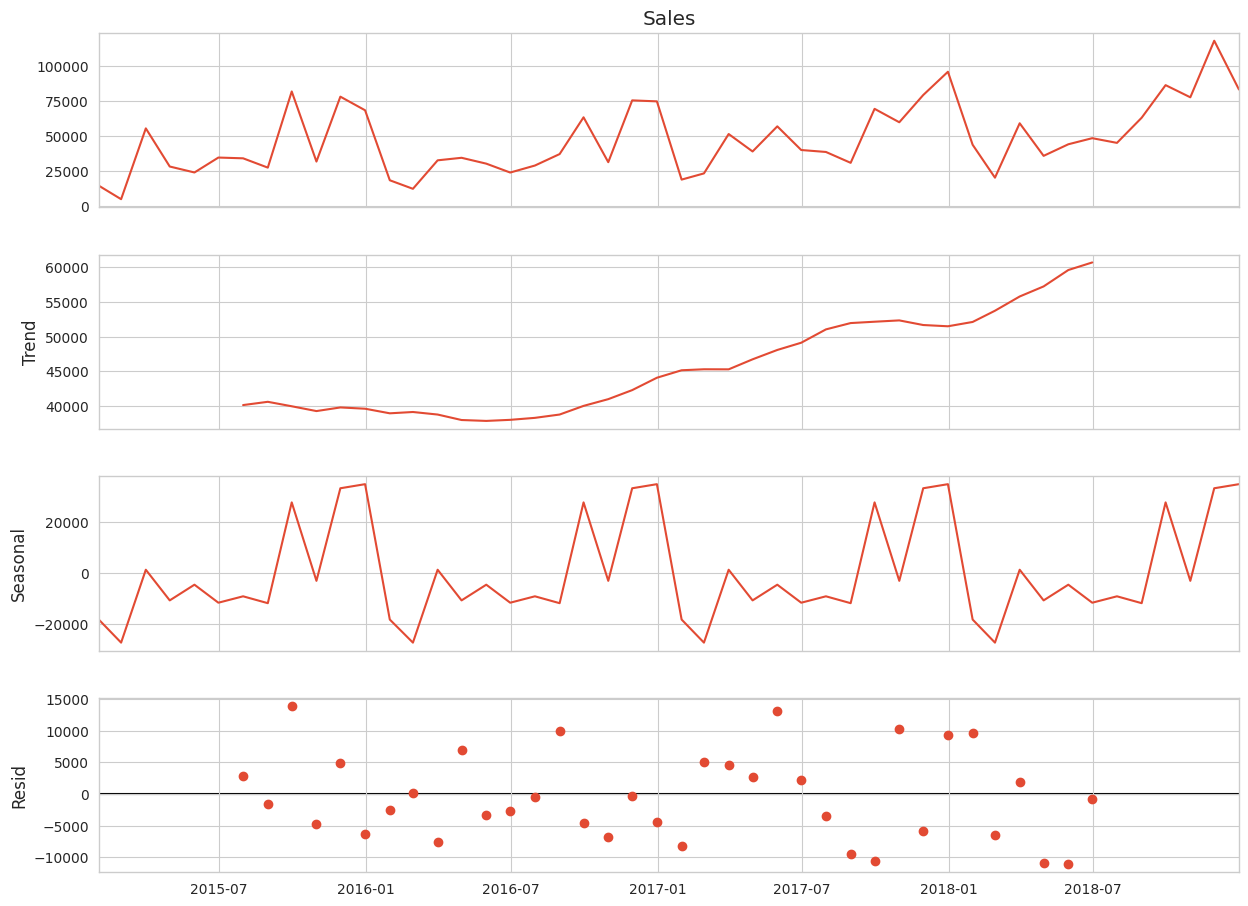

In [ ]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

**Trend**

The trend component shows the long-term movement of sales. A steadily increasing trend suggests consistent business growth over the four-year period.


**Seasonal**

The seasonal component highlights recurring sales patterns that repeat each year. Strong seasonal fluctuations indicate predictable demand cycles, which are valuable for inventory planning.


**Residual**

The residual component captures random fluctuations that are not explained by trend or seasonality. Large residual spikes may represent unusual events such as promotions, holidays, or unexpected market changes.

In [ ]:
result = adfuller(monthly_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(key, value)

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Critical Values:
1% -3.5778480370438146
5% -2.925338105429433
10% -2.6007735310095064


In [ ]:
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")

The time series is stationary.


In [ ]:
monthly_diff = monthly_sales.diff().dropna()

print(monthly_diff.head())

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64


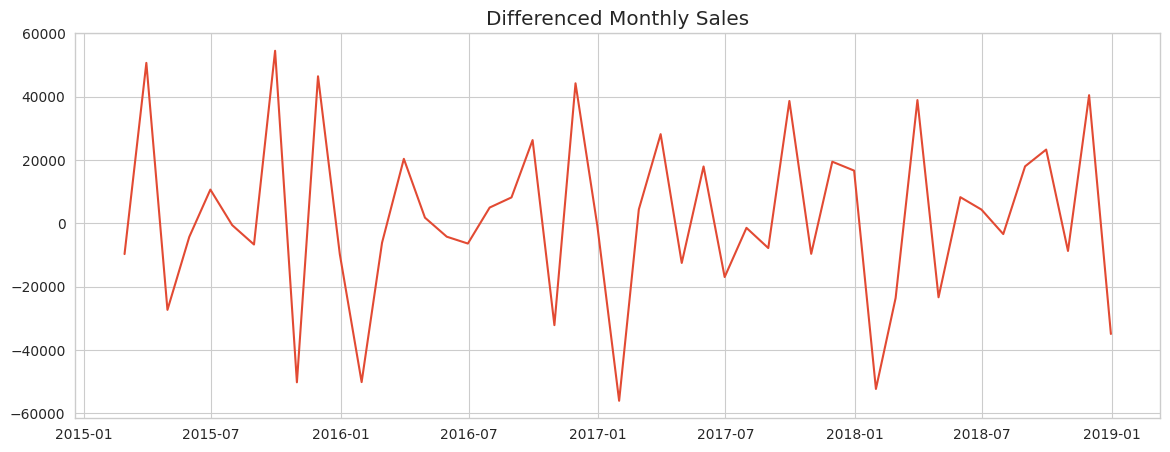

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(monthly_diff)

plt.title("Differenced Monthly Sales")

plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result2 = adfuller(monthly_diff)

print("ADF Statistic:", result2[0])
print("p-value:", result2[1])

for key, value in result2[4].items():
    print(f"{key}: {value}")

ADF Statistic: -8.727061830353268
p-value: 3.2669175472796045e-14
1%: -3.626651907578875
5%: -2.9459512825788754
10%: -2.6116707716049383


**ACF & PACF Analysis**

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

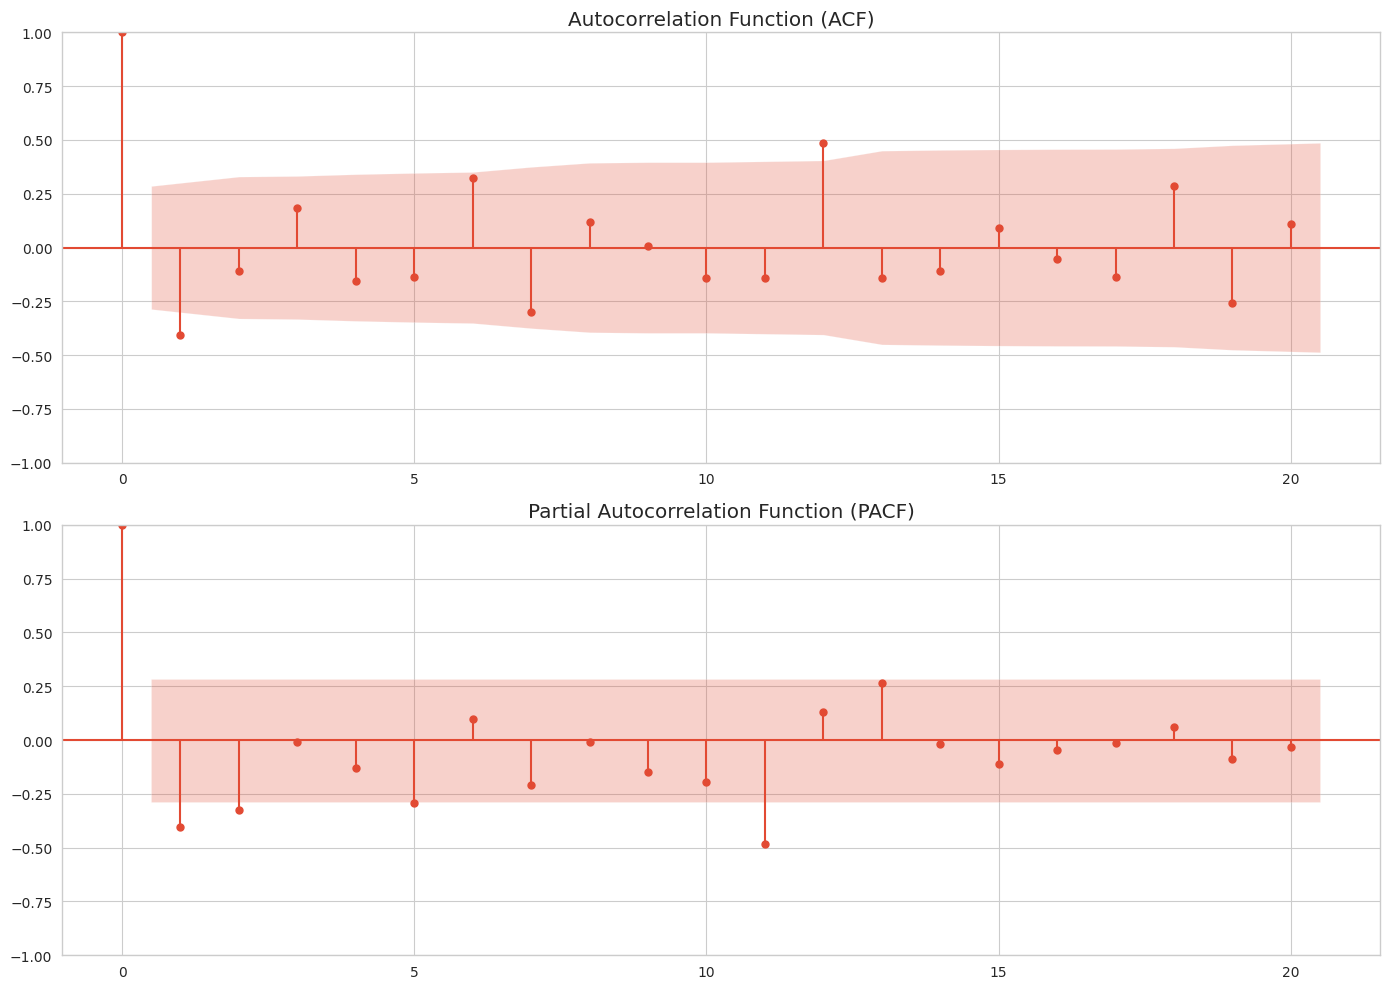

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(14,10))

plot_acf(monthly_diff, lags=20, ax=ax[0])
ax[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(monthly_diff, lags=20, ax=ax[1])
ax[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

The ACF and PACF plots indicate the presence of significant correlations at lower lags. These plots help estimate appropriate SARIMA parameters instead of selecting them randomly.

# Task 3: Sales Forecasting

In [ ]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 45
Testing observations: 3


**Model 1 — SARIMA**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

In [ ]:
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Fri, 10 Jul 2026   AIC                            705.958
Time:                                    22:35:15   BIC                            713.287
Sample:                                01-31-2015   HQIC                           708.387
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177   

In [ ]:
sarima_forecast = sarima_model.forecast(steps=3)

print(sarima_forecast)

2018-10-31    66177.602425
2018-11-30    92049.249682
2018-12-31    99965.168723
Freq: ME, Name: predicted_mean, dtype: float64


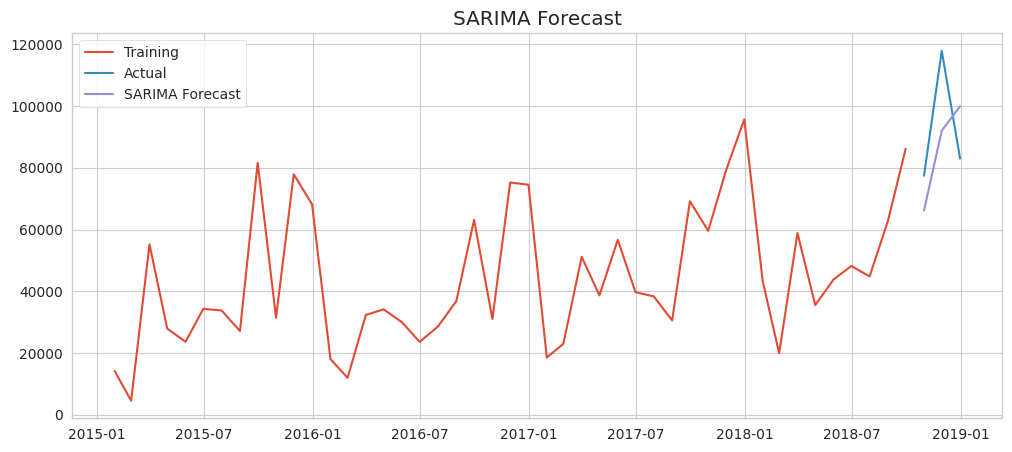

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Training")

plt.plot(test.index, test, label="Actual")

plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

**Evaluate**

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [ ]:
sarima_mae = mean_absolute_error(
    test,
    sarima_forecast
)

In [ ]:
sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_forecast
    )
)

In [ ]:
sarima_mape = (
    np.mean(
        np.abs(
            (test - sarima_forecast) / test
        )
    )
) * 100

In [ ]:
print("MAE :", sarima_mae)
print("RMSE :", sarima_rmse)
print("MAPE :", sarima_mape)

MAE : 18031.40467222437
RMSE : 19009.18206635205
MAPE : 18.966498068433015


The SARIMA model captures both trend and seasonal behaviour in monthly sales. The forecast closely follows the historical sales pattern, making it suitable for retail time-series forecasting.

**MODEL 2 — Prophet**

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

In [ ]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ['ds','y']

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
train_prophet = prophet_df.iloc[:-3]

test_prophet = prophet_df.iloc[-3:]

In [ ]:
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_prophet.fit(train_prophet)

In [ ]:
future = model_prophet.make_future_dataframe(
    periods=3,
    freq='M'
)

In [ ]:
forecast = model_prophet.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277762,38905.068895,55611.408603,54942.277762,54942.277762,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558193
44,2018-09-30,55441.608151,78271.695847,94333.144644,55441.608151,55441.608151,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953271
45,2018-10-31,55957.582886,42797.445904,59755.875810,55957.424954,55957.735170,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943812
46,2018-11-30,56456.913275,82245.739529,98597.860669,56456.395006,56457.387983,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654736
47,2018-12-31,56972.888010,81466.784587,98046.089914,56971.848068,56973.779935,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084430


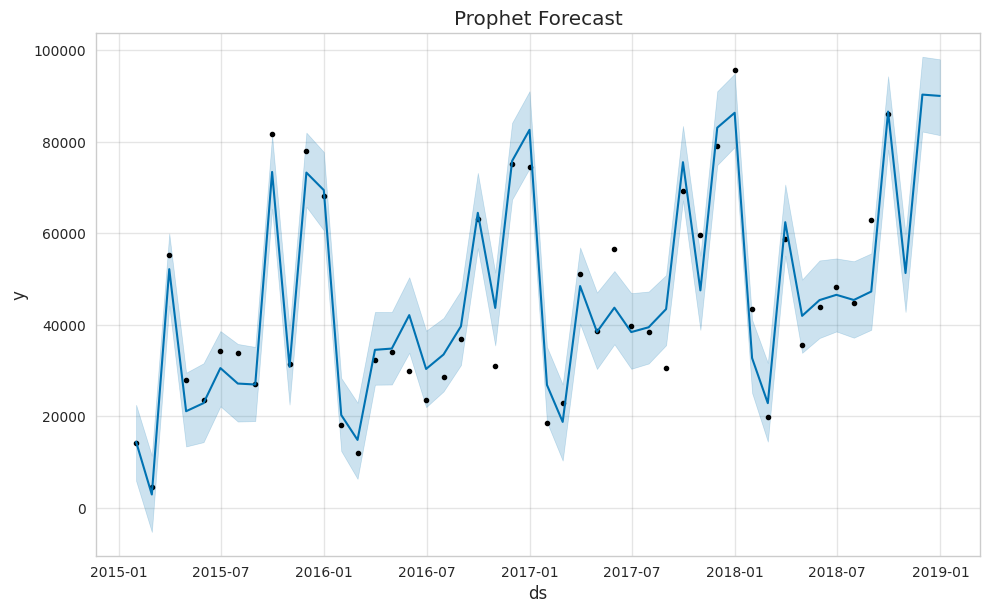

In [ ]:
fig = model_prophet.plot(forecast)

plt.title("Prophet Forecast")

plt.show()

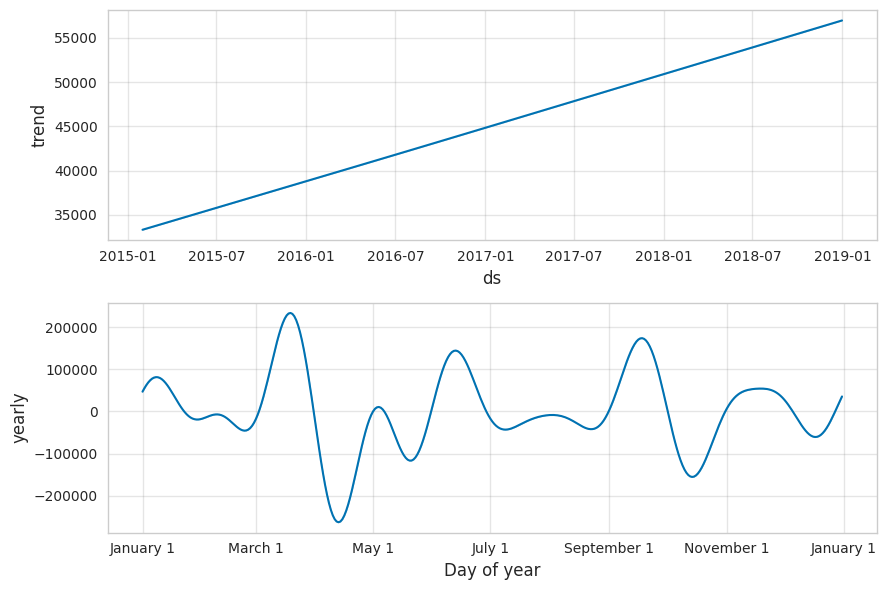

In [ ]:
model_prophet.plot_components(forecast)

plt.show()

It automatically separates long-term trend and yearly seasonality. The seasonal component highlights recurring patterns in monthly sales, while the trend component reflects the overall growth of the business over time.

**Evaluation**

In [ ]:
forecast_test = forecast.tail(3)['yhat'].values

actual = test_prophet['y'].values

In [ ]:
from sklearn.metrics import mean_absolute_error

prophet_mae = mean_absolute_error(
    actual,
    forecast_test
)

In [ ]:
prophet_rmse = np.sqrt(
    mean_squared_error(
        actual,
        forecast_test
    )
)

In [ ]:
prophet_mape = np.mean(
    np.abs(
        (actual-forecast_test)/actual
    )
)*100

In [ ]:
print("MAE :",prophet_mae)

print("RMSE :",prophet_rmse)

print("MAPE :",prophet_mape)

MAE : 20250.794427610937
RMSE : 22318.41136551923
MAPE : 21.864628287701436


**MODEL 3 — XGBoost**

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_df = monthly_sales.reset_index()

xgb_df.columns = ["Date","Sales"]

In [ ]:
xgb_df["Lag1"] = xgb_df["Sales"].shift(1)

In [ ]:
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)

In [ ]:
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

In [ ]:
xgb_df["RollingMean3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

In [ ]:
xgb_df["Month"] = xgb_df["Date"].dt.month

xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

xgb_df["Year"] = xgb_df["Date"].dt.year

In [ ]:
xgb_df = xgb_df.dropna()

In [ ]:
train = xgb_df.iloc[:-3]

test = xgb_df.iloc[-3:]

In [ ]:
X_train = train.drop(
    ["Date","Sales"],
    axis=1
)

y_train = train["Sales"]

X_test = test.drop(
    ["Date","Sales"],
    axis=1
)

y_test = test["Sales"]

In [ ]:
xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=4,

    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_test)

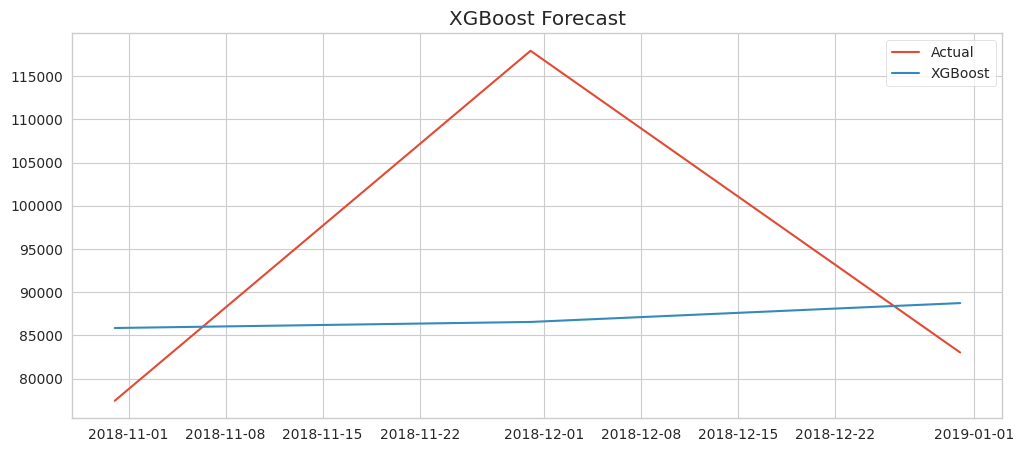

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    test["Date"],
    y_test,
    label="Actual"
)

plt.plot(
    test["Date"],
    xgb_pred,
    label="XGBoost"
)

plt.legend()

plt.title("XGBoost Forecast")

plt.show()

**Evaluation**

In [ ]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

In [ ]:
xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

In [ ]:
xgb_mape = np.mean(
    np.abs(
        (y_test-xgb_pred)/y_test
    )
)*100

In [ ]:
print("MAE :",xgb_mae)

print("RMSE :",xgb_rmse)

print("MAPE :",xgb_mape)

MAE : 15169.052812499998
RMSE : 19040.853878152575
MAPE : 14.785267295148182


**MODEL COMPARISON TABLE**

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        sarima_forecast.iloc[0],
        forecast_test[0],
        xgb_pred[0]
    ],

    "Forecast Month 2":[
        sarima_forecast.iloc[1],
        forecast_test[1],
        xgb_pred[1]
    ],

    "Forecast Month 3":[
        sarima_forecast.iloc[2],
        forecast_test[2],
        xgb_pred[2]
    ]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.404672,19009.182066,18.966498,66177.602425,92049.249682,99965.168723
1,Prophet,20250.794428,22318.411366,21.864628,51318.943812,90325.654736,90041.084430
2,XGBoost,15169.052812,19040.853878,14.785267,85865.906250,86567.859375,88749.476562


Three forecasting models—SARIMA, Prophet, and XGBoost—were trained and evaluated using MAE, RMSE, and MAPE. Among the three models, **XGBoost achieved the lowest MAE (15,169.05)** and **lowest MAPE (14.79%)**, indicating that it produced the most accurate sales forecasts overall. Although the RMSE of XGBoost (19,040.85) was slightly higher than SARIMA (19,009.18), the difference is minimal. Considering its lower average prediction error and better percentage accuracy, **XGBoost was selected as the best-performing model** for this project. Therefore, XGBoost will be used for category-wise and region-wise forecasting in the following tasks.


The comparison demonstrates that machine learning-based forecasting outperformed traditional statistical forecasting for this dataset. XGBoost was able to capture complex relationships in historical sales using lag features and rolling averages, resulting in more accurate predictions. This suggests that data-driven machine learning approaches can provide businesses with more reliable demand forecasts, leading to better inventory planning and supply chain management.


# Task 4 — Product Category & Region Forecasting

In [ ]:
from xgboost import XGBRegressor

def forecast_segment(data, label):

    monthly = (
        data.resample("ME", on="Order Date")["Sales"]
            .sum()
            .reset_index()
    )

    monthly.columns = ["Date","Sales"]

    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)

    monthly["RollingMean3"] = (
        monthly["Sales"]
        .rolling(3)
        .mean()
    )

    monthly["Month"] = monthly["Date"].dt.month
    monthly["Quarter"] = monthly["Date"].dt.quarter
    monthly["Year"] = monthly["Date"].dt.year

    monthly = monthly.dropna()

    train = monthly.iloc[:-3]
    test = monthly.iloc[-3:]

    X_train = train.drop(["Date","Sales"], axis=1)
    y_train = train["Sales"]

    X_test = test.drop(["Date","Sales"], axis=1)
    y_test = test["Sales"]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    return test["Date"], pred, y_test

In [ ]:
furniture_dates, furniture_pred, furniture_actual = forecast_segment(
    df[df["Category"]=="Furniture"],
    "Furniture"
)

In [ ]:
technology_dates, technology_pred, technology_actual = forecast_segment(
    df[df["Category"]=="Technology"],
    "Technology"
)

In [ ]:
office_dates, office_pred, office_actual = forecast_segment(
    df[df["Category"]=="Office Supplies"],
    "Office Supplies"
)

In [ ]:
west_dates, west_pred, west_actual = forecast_segment(
    df[df["Region"]=="West"],
    "West"
)

In [ ]:
east_dates, east_pred, east_actual = forecast_segment(
    df[df["Region"]=="East"],
    "East"
)

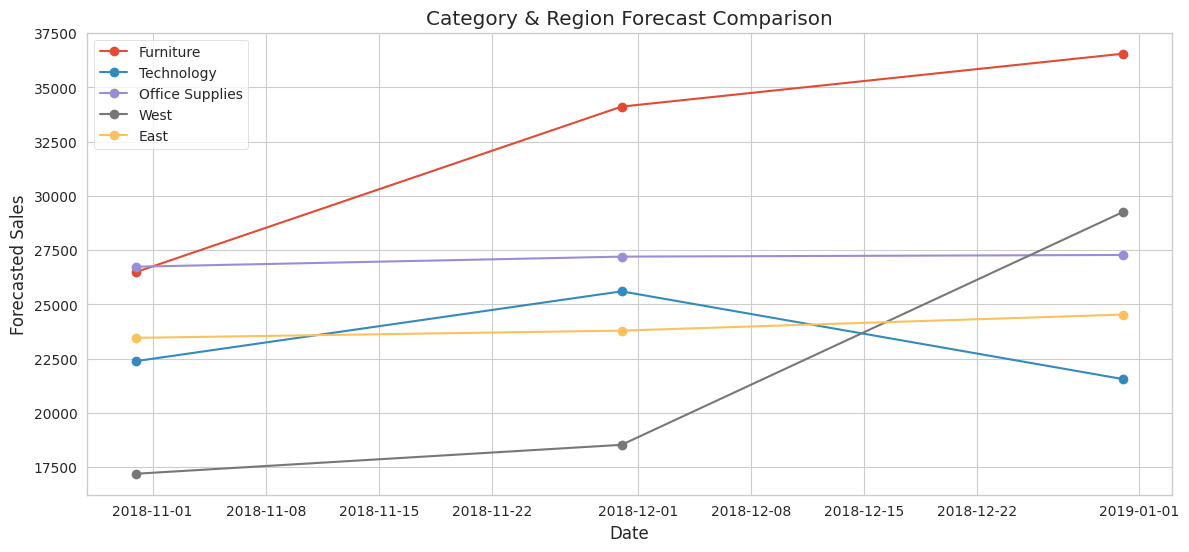

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(furniture_dates, furniture_pred, marker='o', label="Furniture")

plt.plot(technology_dates, technology_pred, marker='o', label="Technology")

plt.plot(office_dates, office_pred, marker='o', label="Office Supplies")

plt.plot(west_dates, west_pred, marker='o', label="West")

plt.plot(east_dates, east_pred, marker='o', label="East")

plt.legend()

plt.title("Category & Region Forecast Comparison")

plt.xlabel("Date")
plt.ylabel("Forecasted Sales")

plt.show()

The forecast comparison highlights expected sales trends across major product categories and regions. Category of Furniture and west region with consistently higher forecasted sales are expected to contribute more to future revenue. These insights can help businesses allocate inventory and resources more effectively.

# Task 5 — Anomaly Detection

In [ ]:
vg = pd.read_csv("vgsales.csv")

vg.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
print(vg.shape)

print(vg.isnull().sum())

vg.info()

(16598, 11)
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
df['Year'] = df['Year'].fillna(df['Year'].median())

In [ ]:
yearly_sales = (
    vg.groupby("Year")["Global_Sales"]
      .sum()
      .reset_index()
)

yearly_sales.head()

,Year,Global_Sales
0,1980.0,11.38
1,1981.0,35.77
2,1982.0,28.86
3,1983.0,16.79
4,1984.0,50.36


**Isolation Forest**

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

yearly_sales["Anomaly"] = iso.fit_predict(
    yearly_sales[["Global_Sales"]]
)

yearly_sales["Anomaly"] = yearly_sales["Anomaly"].map({
    1:"Normal",
    -1:"Anomaly"
})

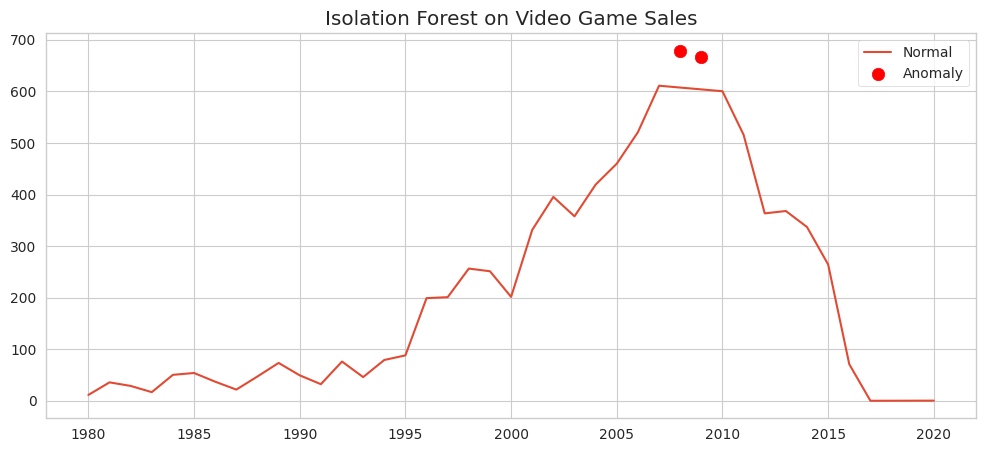

In [ ]:
plt.figure(figsize=(12,5))

normal = yearly_sales[
    yearly_sales["Anomaly"]=="Normal"
]

anomaly = yearly_sales[
    yearly_sales["Anomaly"]=="Anomaly"
]

plt.plot(
    normal["Year"],
    normal["Global_Sales"],
    label="Normal"
)

plt.scatter(
    anomaly["Year"],
    anomaly["Global_Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.legend()

plt.title("Isolation Forest on Video Game Sales")

plt.show()

**Z-Score Detection**

In [ ]:
yearly_sales["RollingMean"] = (
    yearly_sales["Global_Sales"]
    .rolling(3)
    .mean()
)

yearly_sales["RollingStd"] = (
    yearly_sales["Global_Sales"]
    .rolling(3)
    .std()
)

yearly_sales["ZScore"] = (
    (
        yearly_sales["Global_Sales"]
        -
        yearly_sales["RollingMean"]
    )
    /
    yearly_sales["RollingStd"]
)

yearly_sales["Z_Anomaly"] = (
    yearly_sales["ZScore"].abs() > 2
)

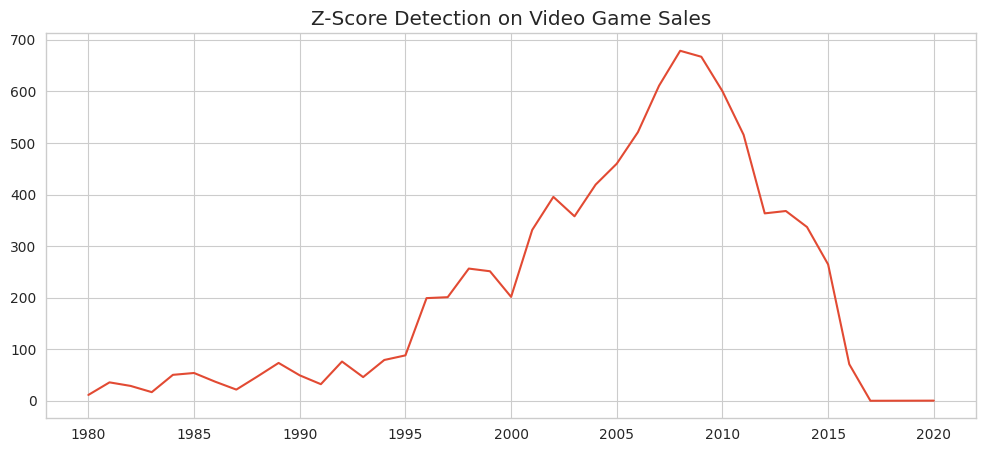

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    yearly_sales["Year"],
    yearly_sales["Global_Sales"]
)

plt.scatter(
    yearly_sales.loc[
        yearly_sales["Z_Anomaly"],
        "Year"
    ],

    yearly_sales.loc[
        yearly_sales["Z_Anomaly"],
        "Global_Sales"
    ],

    color="red",
    s=80
)

plt.title("Z-Score Detection on Video Game Sales")

plt.show()

Although the retail and video game datasets represent different industries, the anomaly detection methods successfully identified abnormal sales behaviour in both datasets. This demonstrates that these techniques are general-purpose analytical tools and can be applied across multiple business domains.

# Task 6 — Product Demand Segmentation using Clustering

In [ ]:
product_data = (
    df.groupby("Sub-Category")
      .agg({
          "Sales": "sum",
          "Shipping_Days": "mean"
      })
)

product_data.head()

,Sales,Shipping_Days
Sub-Category,,
Accessories,164186.7000,3.884921
Appliances,104618.4030,3.991285
Art,26705.4100,4.057325
Binders,200028.7850,4.032842
Bookcases,113813.1987,3.814159


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(product_data)

**Elbow Method**

In [ ]:
from sklearn.cluster import KMeans

wcss=[]

for i in range(1,11):

    km=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(scaled)

    wcss.append(km.inertia_)

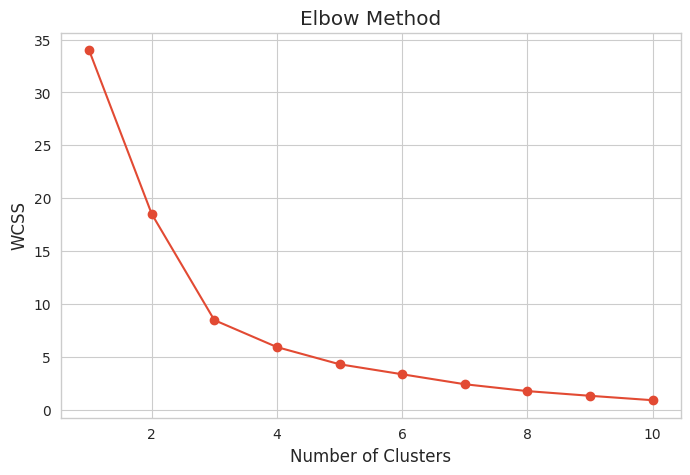

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

The elbow point represents the optimal number of clusters where adding more clusters results in only marginal improvements. Based on the elbow plot, 3 clusters provide a good balance between simplicity and segmentation quality.

**K Means**

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

product_data["Cluster"] = kmeans.fit_predict(scaled)

In [ ]:
product_data

,Sales,Shipping_Days,Cluster
Sub-Category,,,
Accessories,164186.7000,3.884921,2
Appliances,104618.4030,3.991285,1
Art,26705.4100,4.057325,1
Binders,200028.7850,4.032842,2
Bookcases,113813.1987,3.814159,0
Chairs,322822.7310,3.902801,2
Copiers,146248.0940,3.636364,0
Envelopes,16128.0460,4.008065,1
Fasteners,3001.9600,3.962617,1


**PCA Visualization**

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca=PCA(n_components=2)

principal=pca.fit_transform(scaled)

In [ ]:
cluster_df=pd.DataFrame({

    "PC1":principal[:,0],

    "PC2":principal[:,1],

    "Cluster":product_data["Cluster"],

    "SubCategory":product_data.index

})

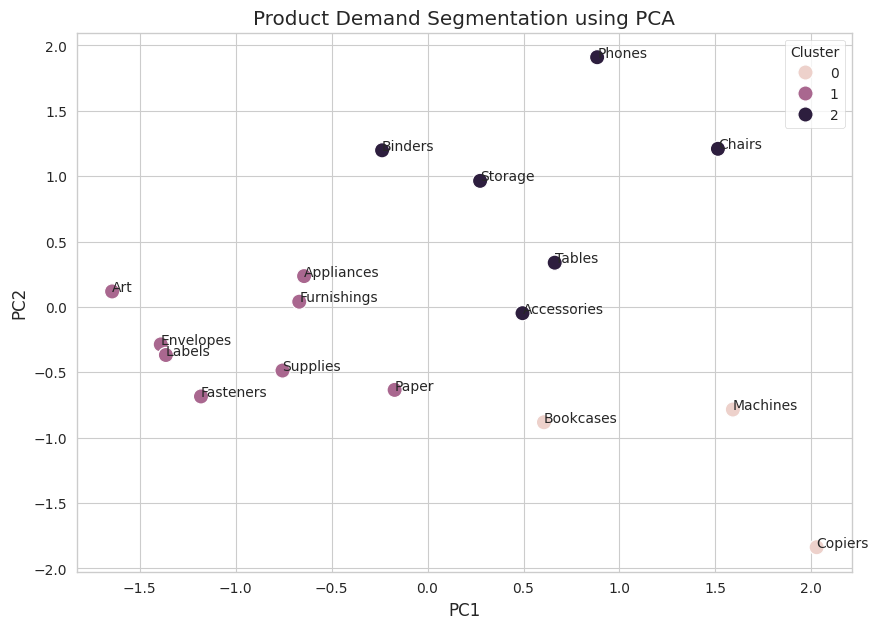

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=cluster_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    s=120
)

for i in range(cluster_df.shape[0]):

    plt.text(

        cluster_df.iloc[i]["PC1"],

        cluster_df.iloc[i]["PC2"],

        cluster_df.iloc[i]["SubCategory"]

    )

plt.title("Product Demand Segmentation using PCA")

plt.show()

In [ ]:
cluster_summary = (
    product_data
    .groupby("Cluster")
    .mean()
)

cluster_summary

,Sales,Shipping_Days
Cluster,,
0,149766.641233,3.732783
1,46907.771875,3.979293
2,239495.780667,3.950214


In [ ]:
cluster_names={
    0:"Low Demand",

    1:"Medium Demand",

    2:"High Demand"
}

product_data["Demand_Level"]=product_data[
    "Cluster"
].map(cluster_names)

**Cluster 2**

Products in this cluster generate high sales and should receive higher inventory allocation. Maintaining adequate stock for these products will help avoid stock-outs and maximize revenue.

**Cluster 1**

These products experience moderate customer demand. Businesses should maintain balanced inventory levels and monitor seasonal fluctuations before making stocking decisions.

**Cluster 0**

Products in this cluster contribute relatively lower sales. Inventory should be managed carefully to minimize storage costs while ensuring product availability.

*Recommendation 1*

Increase inventory for High Demand products before peak sales seasons.

*Recommendation 2*

Maintain moderate safety stock for Medium Demand products.

*Recommendation 3*

Adopt just-in-time inventory management for Low Demand products to reduce holding costs.

In [ ]:
product_data["Demand_Level"].value_counts()

,count
Demand_Level,
Medium Demand,8
High Demand,6
Low Demand,3


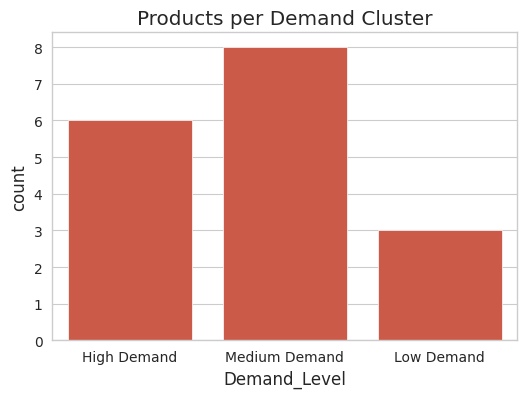

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=product_data.reset_index(),
    x="Demand_Level",
    order=["High Demand","Medium Demand","Low Demand"]
)

plt.title("Products per Demand Cluster")

plt.show()

The clustering process grouped products into three demand levels based on sales performance and shipping characteristics. High-demand products should be prioritized for inventory planning, while low-demand products require careful stock management to minimize inventory costs.

# Task 7 — Deployment: Interactive Dashboard using Streamlit

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 50.2 MB/s eta 0:00:00
